# 03 — Dataset Health Check

Diagnostic-only inspection of `data/dataset/` (built by notebook 02): per-split class balance, box-size distribution, image dimensions, empty/degenerate labels, and cross-split leakage. No files are modified.

In [1]:
# Install dependencies
%pip install -q pandas pillow matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [3]:
# Config — paths, classes, thresholds
DST = Path('../data/dataset')   # unified dataset from notebook 02

CLASSES = ['projector', 'whiteboard', 'fire_extinguisher', 'door_sign']
SPLITS = ['train', 'val', 'test']

TINY_BOX_AREA = 1e-3   # normalized area below this is flagged as 'tiny' (~ <20×20 px on a 640 image)

assert (DST / 'data.yaml').exists(), 'run notebook 02 first to build data/dataset/'

## 1. Load every label into one DataFrame
One row per box; images with no labels get a single row with NaN columns.

In [4]:
# Aggregate labels + image dims across all splits
rows = []
for split in SPLITS:
    img_dir = DST / 'images' / split; lbl_dir = DST / 'labels' / split
    for img in img_dir.glob('*.jpg'):
        with Image.open(img) as im:
            W, H = im.size
        lbl = lbl_dir / (img.stem + '.txt')
        boxes = 0
        if lbl.exists():
            for line in lbl.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) != 5: continue
                cid, xc, yc, w, h = map(float, parts)
                rows.append({'split': split, 'file': img.name, 'W': W, 'H': H,
                             'class': CLASSES[int(cid)], 'bx_w': w, 'bx_h': h, 'bx_area': w*h})
                boxes += 1
        if boxes == 0:
            rows.append({'split': split, 'file': img.name, 'W': W, 'H': H,
                         'class': None, 'bx_w': None, 'bx_h': None, 'bx_area': None})

df = pd.DataFrame(rows)
print('rows (one per box, or one per empty image):', len(df))
df.head()

rows (one per box, or one per empty image): 863


,split,file,W,H,class,bx_w,bx_h,bx_area
0,train,0001_projector.jpg,640,640,projector,0.706250,0.504687,0.356436
1,train,0003_projector.jpg,4608,2080,NaN,NaN,NaN,NaN
2,train,0004_projector.jpg,640,640,projector,0.562500,0.703125,0.395508
3,train,0005_projector.jpg,640,640,projector,0.767188,0.473438,0.363215
4,train,0006_projector.jpg,640,640,projector,0.518750,0.750000,0.389063


## 2. Per-split class balance

class,door_sign,fire_extinguisher,projector,whiteboard
split,,,,
train,106,140,115,140
val,28,40,33,40
test,16,20,17,20


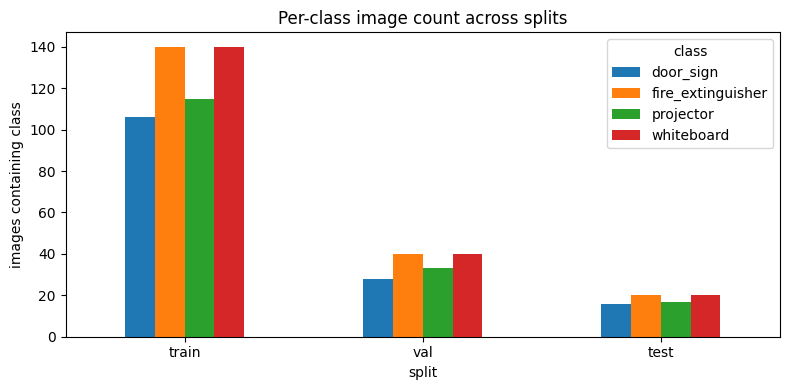

In [5]:
# Image counts per class per split + bar chart
per_img = df.dropna(subset=['class']).drop_duplicates(subset=['split', 'file', 'class'])
table = per_img.groupby(['split', 'class']).size().unstack(fill_value=0).reindex(SPLITS)
display(table)

ax = table.plot.bar(figsize=(8, 4))
ax.set_ylabel('images containing class'); ax.set_title('Per-class image count across splits')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 3. Box-size distribution per class
Tiny boxes (area below `TINY_BOX_AREA`) are hard for the detector and worth flagging.

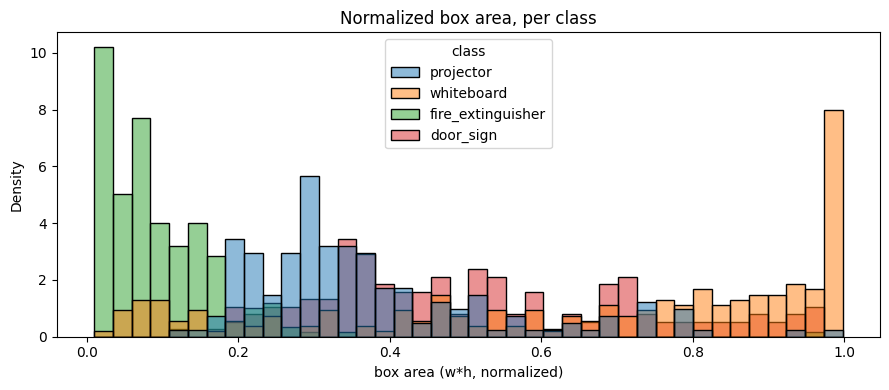

tiny boxes (<0.001 area): 0 / 778


In [6]:
# Box area histogram per class + tiny-box count
boxes = df.dropna(subset=['bx_area'])
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=boxes, x='bx_area', hue='class', bins=40, stat='density', common_norm=False, ax=ax)
ax.set_title('Normalized box area, per class'); ax.set_xlabel('box area (w*h, normalized)')
plt.tight_layout(); plt.show()

tiny = boxes[boxes['bx_area'] < TINY_BOX_AREA]
print(f'tiny boxes (<{TINY_BOX_AREA} area): {len(tiny)} / {len(boxes)}')

## 4. Image dimensions
Confirms training `imgsz=640` is reasonable for the source resolutions.

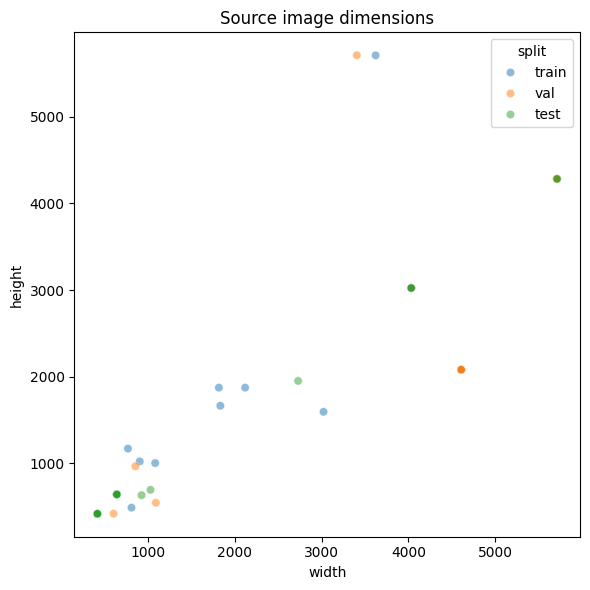

,W,H
count,800.000000,800.000000
mean,898.140000,751.173750
std,1351.003665,933.842196
min,416.000000,416.000000
25%,416.000000,416.000000
50%,416.000000,416.000000
75%,640.000000,640.000000
max,5712.000000,5712.000000


In [7]:
# W/H scatter per split
dims = df.drop_duplicates(subset=['split', 'file'])[['split', 'W', 'H']]
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=dims, x='W', y='H', hue='split', alpha=0.5, ax=ax)
ax.set_title('Source image dimensions'); ax.set_xlabel('width'); ax.set_ylabel('height')
plt.tight_layout(); plt.show()
dims.describe()

## 5. Empty / degenerate labels
YOLO accepts unlabeled images as background, but too many bias the detector. Confirm the split isn't accidentally unlabeled.

In [8]:
# Per-split summary: images, empty labels, total boxes, tiny boxes
by_split = df.groupby('split')
summary = pd.DataFrame({
    'images':        by_split['file'].nunique(),
    'empty_labels':  by_split.apply(lambda g: g[g['class'].isna()]['file'].nunique()),
    'boxes':         by_split['bx_area'].count(),
    'tiny_boxes':    by_split.apply(lambda g: int((g['bx_area'] < TINY_BOX_AREA).sum())),
}).reindex(SPLITS)
summary

,images,empty_labels,boxes,tiny_boxes
split,,,,
train,560,59,544,0
val,160,19,155,0
test,80,7,79,0


## 6. Cross-split leakage
Same filename must not appear in more than one split.

In [9]:
# Detect filenames present in multiple splits
files = df.drop_duplicates(subset=['split', 'file'])[['split', 'file']]
dups = files.groupby('file')['split'].nunique()
leaked = dups[dups > 1]
print('filenames appearing in multiple splits:', len(leaked))
leaked.head()

filenames appearing in multiple splits: 0


Series([], Name: split, dtype: int64)

### Health checklist
- [ ] Every class present in every split
- [ ] No split dominated by one class (skew < ~2×)
- [ ] `empty_labels` is 0 (or intentionally small)
- [ ] `tiny_boxes` / `boxes` ≤ 5%
- [ ] `leaked` is 0
- [ ] Image dimensions consistent with `imgsz=640`

If all checks pass, proceed to **notebook 04** for training.